#### Load Trained DUCK-Net Model

In [4]:
import sys
sys.path.append('../src')

import tensorflow as tf
from biliary_seg.models.ducknet import DUCK_Net

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

model = DUCK_Net.create_model(
    img_height=512,
    img_width=512,
    input_chanels=3,
    out_classes=1,
    starting_filters=17,
)
model.load_weights('../model_weights/best_dice_model-8-512.h5')

Starting DUCK-Net


#### Predict Mask on a Processed Image

In [7]:
from biliary_seg.data.image_loader import ImageLoader
from biliary_seg.data.inference.predict import predict_mask

image_loader = ImageLoader.from_data_dir(id='131_roi_0', data_dir='../data/processed')

mask = predict_mask(
    image=image_loader.image,
    model=model,
    image_size=(512, 512),
    window_overlap=0.35,
    threshold=0.5,
    batch_size=4,
)

#### Visualise Prediction

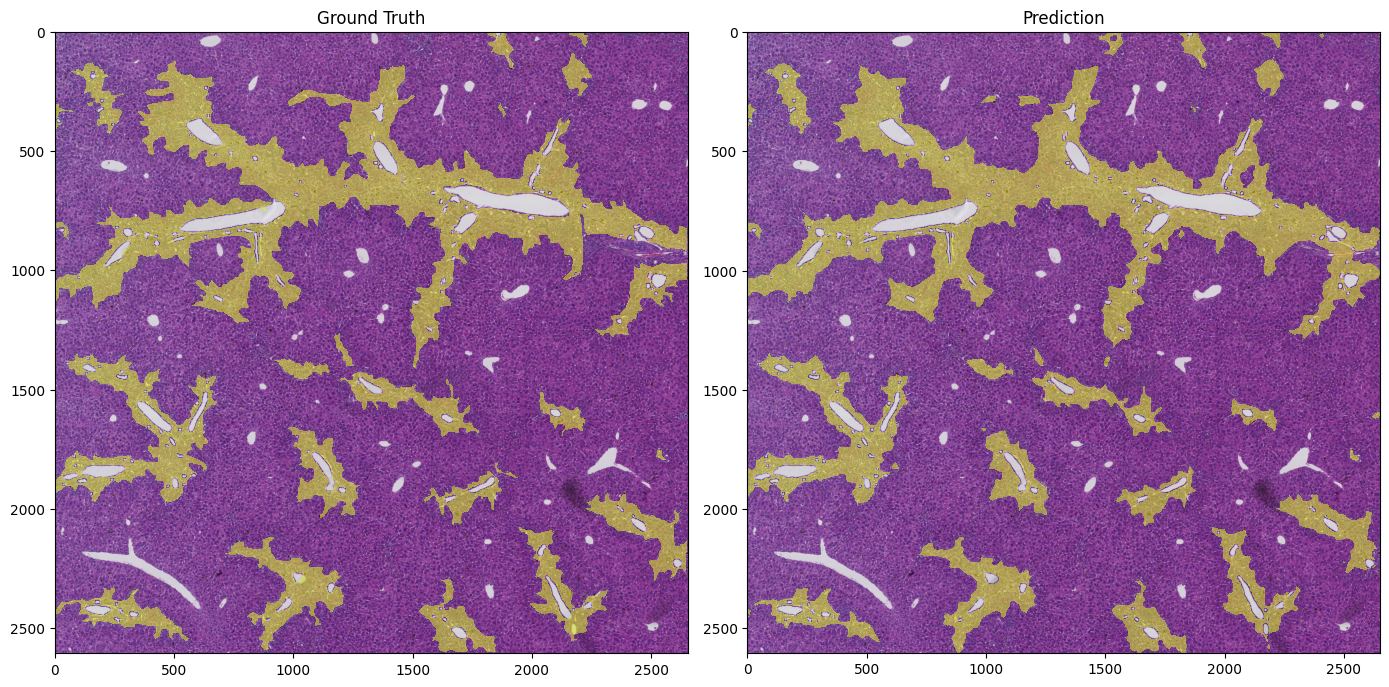

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].set_title('Ground Truth')
axes[0].imshow(image_loader.image)
gt_mask = np.ma.masked_where(image_loader.mask == 0, image_loader.mask)
axes[0].imshow(gt_mask, alpha=0.5, cmap='plasma_r')

axes[1].set_title('Prediction')
axes[1].imshow(image_loader.image)
pred_mask = np.ma.masked_where(mask == 0, mask)
axes[1].imshow(pred_mask, alpha=0.5, cmap='plasma_r')

fig.tight_layout()

#### Export Prediction as GeoJSON

The exported GeoJSON can be loaded back into QuPath. The `scale_factor` should match the `downsample_factor` used during preprocessing so the contours align with the native slide coordinates.

In [ ]:
from biliary_seg.data.geometry.geojson_export import mask_to_geojson, save_geojson

geojson = mask_to_geojson(mask=mask, scale_factor=8)
save_geojson(geojson=geojson, filepath='../data/processed/predictions/RG425_roi_0.geojson')